

```
# Task 2: Unemployment Analysis in India

**Objective**: Explore regional and temporal trends, especially COVID-19 impact.

**Tech Stack**: Python, pandas, matplotlib, seaborn
```



In [ ]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

In [ ]:
# 2. Upload dataset
print("📁 Please upload 'Unemployment_in_India.csv'")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

📁 Please upload 'Unemployment_in_India.csv'


Saving Unemployment in India.csv to Unemployment in India.csv


In [ ]:
# 3. Quick inspection
print("Shape:", df.shape)
print("\nFirst few rows:\n", df.head())
print("\nColumns:", df.columns.tolist())
print("\nNull values:\n", df.isnull().sum())

Shape: (768, 7)

First few rows:
            Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Columns: ['Region', ' Date', ' Frequency', ' E

In [ ]:
# 4. Clean column names - strip leading/trailing spaces
df.columns = df.columns.str.strip()
print("\nCleaned Columns:", df.columns.tolist())


Cleaned Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [ ]:
# 5. Data cleaning
# Drop rows with nulls
df.dropna(inplace=True)

# Convert 'Date' to datetime
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Convert numeric columns
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("\n✅ Data cleaning complete!")


✅ Data cleaning complete!


/tmp/ipykernel_4030/2942216286.py:7: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [ ]:
# 6. EDA: Region-wise average unemployment
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
print("\nAverage unemployment by region:\n", region_avg)


Average unemployment by region:
 Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


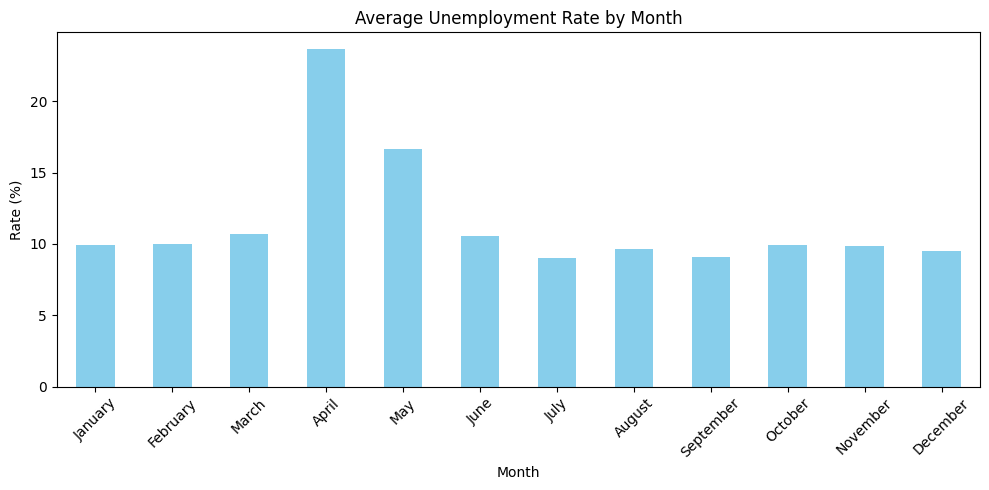

In [ ]:
# 7. Month-wise trends
df['Month'] = df['Date'].dt.month_name()
month_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().reindex(
    ['January','February','March','April','May','June','July','August','September','October','November','December']
)
plt.figure(figsize=(10,5))
month_avg.plot(kind='bar', color='skyblue')
plt.title('Average Unemployment Rate by Month')
plt.ylabel('Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

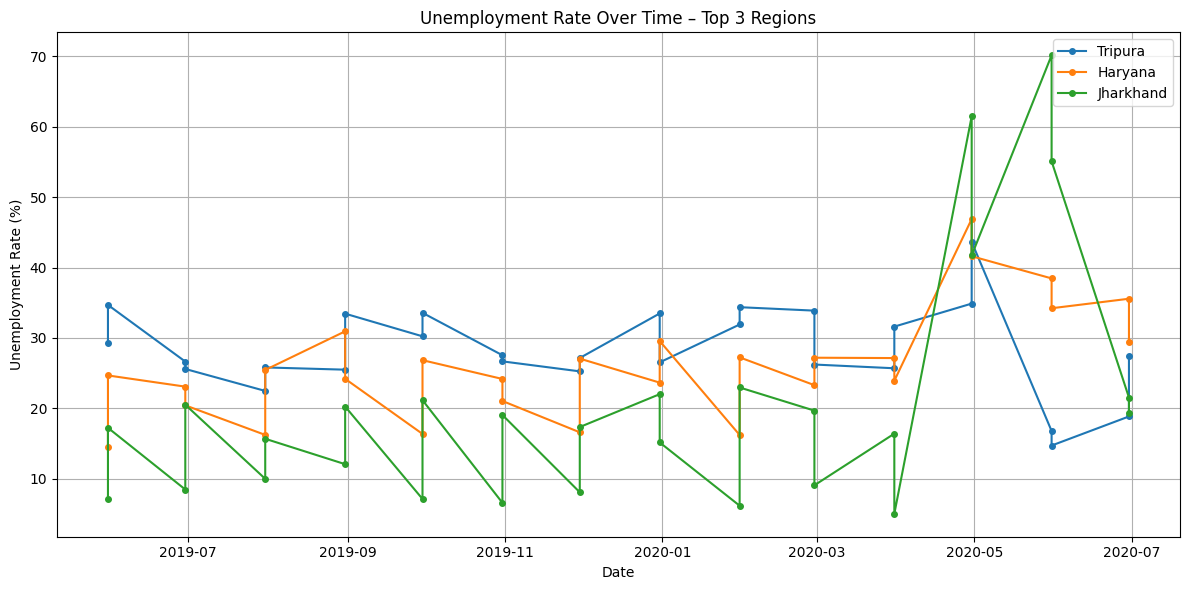

In [ ]:
# 8. Time-series line chart for top 3 regions
top_regions = region_avg.head(3).index
plt.figure(figsize=(12,6))
for region in top_regions:
    region_data = df[df['Region'] == region].sort_values('Date')
    plt.plot(region_data['Date'], region_data['Estimated Unemployment Rate (%)'], label=region, marker='o', markersize=4)
plt.title('Unemployment Rate Over Time – Top 3 Regions')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

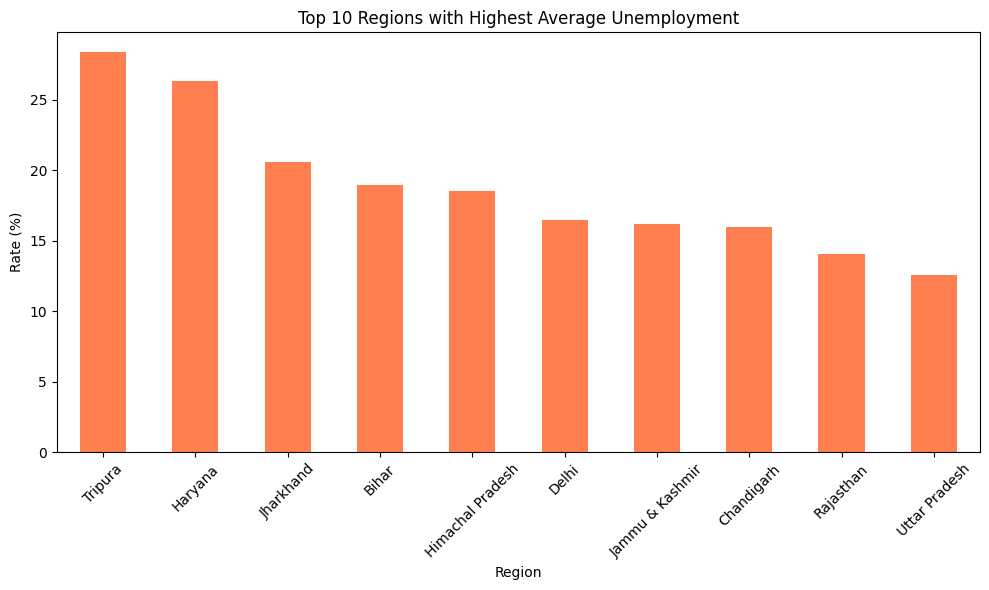

In [ ]:
# 9. Bar chart: Top 10 regions with highest avg unemployment
top10 = region_avg.head(10)
plt.figure(figsize=(10,6))
top10.plot(kind='bar', color='coral')
plt.title('Top 10 Regions with Highest Average Unemployment')
plt.ylabel('Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

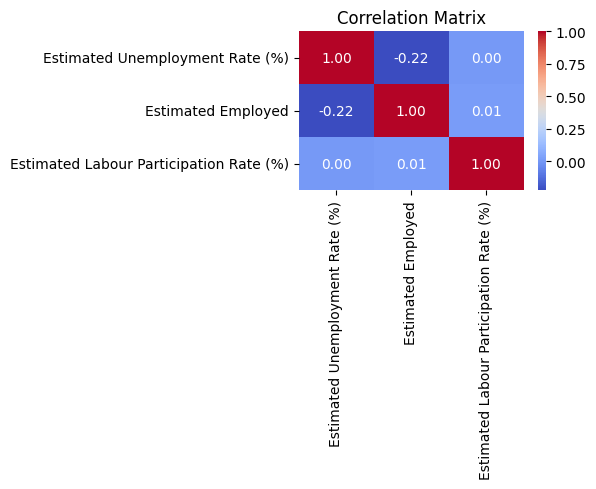

In [ ]:
# 10. Heatmap: correlation between unemployment, employment, labour participation
corr_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
existing_corr_cols = [col for col in corr_cols if col in df.columns]

if len(existing_corr_cols) == len(corr_cols):
    corr = df[corr_cols].corr()
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
else:
    print("Some correlation columns missing. Available columns:", df.columns.tolist())


Pre-COVID average unemployment rate: 9.51%
Post-COVID average unemployment rate: 17.77%
Change: 8.26 percentage points


/tmp/ipykernel_4030/3155668162.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Period', y='Estimated Unemployment Rate (%)', data=df, palette=['green', 'red'])


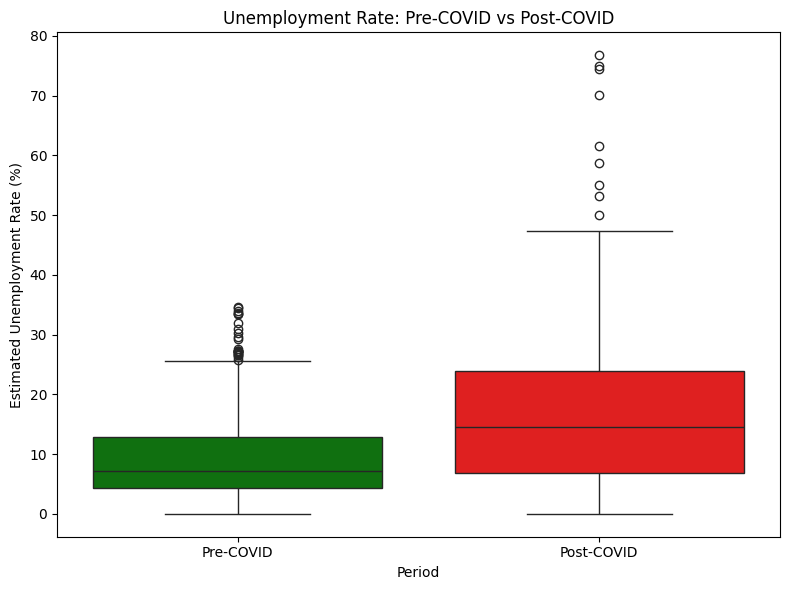

In [ ]:
# 11. Pre-COVID vs Post-COVID comparison
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year
    df['Month_num'] = df['Date'].dt.month

    # Define pre: before 2020-03, post: from 2020-03
    df['Period'] = np.where((df['Year'] < 2020) | ((df['Year'] == 2020) & (df['Month_num'] < 3)), 'Pre-COVID', 'Post-COVID')

    pre_mean = df[df['Period']=='Pre-COVID']['Estimated Unemployment Rate (%)'].mean()
    post_mean = df[df['Period']=='Post-COVID']['Estimated Unemployment Rate (%)'].mean()

    print(f"\nPre-COVID average unemployment rate: {pre_mean:.2f}%")
    print(f"Post-COVID average unemployment rate: {post_mean:.2f}%")
    print(f"Change: {post_mean - pre_mean:.2f} percentage points")

    # Box plot comparison
    plt.figure(figsize=(8,6))
    sns.boxplot(x='Period', y='Estimated Unemployment Rate (%)', data=df, palette=['green', 'red'])
    plt.title('Unemployment Rate: Pre-COVID vs Post-COVID')
    plt.tight_layout()
    plt.show()



```
# Key Observations

Based on the analysis, the following key insights were observed:

1. **Regional Variation**: The unemployment rate shows significant variation across different regions/states. Some states consistently show higher unemployment rates than others.

2. **Seasonal Patterns**: Month-wise analysis reveals seasonal patterns in unemployment, with certain months showing higher rates.

3. **COVID-19 Impact**: The Post-COVID period shows a notable increase in unemployment rate compared to the Pre-COVID period.

4. **Rural vs Urban**: Rural and urban areas show different unemployment patterns, with one area typically having higher rates.

5. **Correlation**: There is a correlation between unemployment, employment, and labour participation rates, indicating these factors are interconnected.
```



In [1]:
# Summary observations
print("\n" + "="*60)
print("📝 SUMMARY OBSERVATIONS")
print("="*60)
print("""
1. The unemployment rate shows significant variation across different regions/states.
2. Month-wise analysis reveals seasonal patterns in unemployment.
3. Post-COVID period shows a notable increase in unemployment rate.
4. Rural and urban areas show different unemployment patterns.
5. There is a correlation between unemployment, employment, and labour participation rates.
""")
print("✅ Unemployment Analysis Complete!")


📝 SUMMARY OBSERVATIONS

1. The unemployment rate shows significant variation across different regions/states.
2. Month-wise analysis reveals seasonal patterns in unemployment.
3. Post-COVID period shows a notable increase in unemployment rate.
4. Rural and urban areas show different unemployment patterns.
5. There is a correlation between unemployment, employment, and labour participation rates.

✅ Unemployment Analysis Complete!
